# Day 1 — ENSOcast data plumbing

Open ERSSTv5 over the network (no manual download), crop the tropical Pacific, convert to anomalies, pull ONI, and align it to months.

**Open in Colab after you push this repo:**
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aarib-sami/ninonet/blob/main/enso/day1_data.ipynb)

## 0. Install packages

In [ ]:
# xarray   — open/slice NetCDF climate grids (SST maps) with named dims (time, lat, lon)
# netCDF4  — backend so xarray can actually read .nc / OPeNDAP files
# numpy    — array math once data is out of xarray (stacking samples later, etc.)
# pandas   — read/align the ONI text table as a time series
# matplotlib — quick sanity plots of anomaly maps
!pip install -q xarray netCDF4 numpy pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.4 MB/s eta 0:00:00


## 1. (Optional) Mount Drive and save outputs there

Skip this cell if you only want files for this runtime. Mount if you want `pacific_anom.nc` to survive after Colab disconnects.

In [3]:
from pathlib import Path

USE_DRIVE = True  # set False to keep everything in /content

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_DIR = Path("/content/drive/MyDrive/ensocast/data")
else:
    DATA_DIR = Path("/content/ensocast/data")

DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Saving to:", DATA_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving to: /content/drive/MyDrive/ensocast/data


## 2. Open ERSSTv5 monthly SST (streamed, no browser download)

This is the **Mean** monthly product — a stack of global SST maps, one per month since 1854.

In [4]:
import xarray as xr

url = "https://psl.noaa.gov/thredds/dodsC/Datasets/noaa.ersst.v5/sst.mnmean.nc"
ds = xr.open_dataset(url)
ds

<xarray.Dataset> Size: 133MB
Dimensions:    (time: 2071, nbnds: 2, lat: 89, lon: 180)
Coordinates:
  * time       (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-07-01
  * lat        (lat) float32 356B 88.0 86.0 84.0 82.0 ... -84.0 -86.0 -88.0
  * lon        (lon) float32 720B 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 33kB ...
    sst        (time, lat, lon) float32 133MB ...
Attributes: (12/39)
    climatology:                     Climatology is based on 1971-2000 SST, X...
    description:                     In situ data: ICOADS2.5 before 2007 and ...
    keywords_vocabulary:             NASA Global Change Master Directory (GCM...
    keywords:                        Earth Science > Oceans > Ocean Temperatu...
    instrument:                      Conventional thermometers
    source_comment:                  SSTs were observed by conventional therm...
    ...                              ...
    comment:                         SSTs were observed by conventional therm...
    summary:                         ERSST.v5 is developed based on v4 after ...
    dataset_title:                   NOAA Extended Reconstructed SST V5
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    data_modified:                   2026-08-03
    DODS_EXTRA.Unlimited_Dimension:  time

## 3. Crop tropical Pacific, keep 1950 onward

In [5]:
# lon is 0–360: 120E to 280E covers the tropical Pacific box used here
sst = ds["sst"].sel(lat=slice(30, -30), lon=slice(120, 280))
sst = sst.sel(time=slice("1950-01-01", None))
print(sst)

<xarray.DataArray 'sst' (time: 919, lat: 31, lon: 81)> Size: 9MB
[2307609 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 ... 2026-07-01
  * lat      (lat) float32 124B 30.0 28.0 26.0 24.0 ... -24.0 -26.0 -28.0 -30.0
  * lon      (lon) float32 324B 120.0 122.0 124.0 126.0 ... 276.0 278.0 280.0
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]
    _ChunkSizes:   [  1  89 180]


## 4. Convert to anomalies (departure from each month's long-term average)

In [6]:
climatology = sst.groupby("time.month").mean("time")
anom = sst.groupby("time.month") - climatology
anom = anom.fillna(0.0)  # land / missing cells → 0

out_path = DATA_DIR / "pacific_anom.nc"
anom.to_netcdf(out_path)
print("Wrote", out_path)
print(anom)

Wrote /content/drive/MyDrive/ensocast/data/pacific_anom.nc
<xarray.DataArray 'sst' (time: 919, lat: 31, lon: 81)> Size: 9MB
array([[[ 0.        ,  1.532135  ,  1.1841974 , ...,  2.4503536 ,
          0.        ,  1.3263683 ],
        [ 0.        ,  1.3262653 ,  1.0440788 , ...,  2.0278187 ,
          1.8031025 ,  1.2332249 ],
        [ 0.96777916,  0.9412899 ,  0.7166424 , ...,  1.4013958 ,
          1.3526726 ,  0.8950615 ],
        ...,
        [ 0.        ,  0.        ,  0.        , ..., -0.36826134,
         -0.22566605, -0.02421761],
        [ 0.        ,  0.        ,  0.        , ..., -0.42986298,
         -0.31567383, -0.12870216],
        [ 0.        ,  0.        ,  0.        , ..., -0.46082687,
         -0.36213303, -0.20757484]],

       [[ 0.        ,  1.9376163 ,  1.6002731 , ...,  2.4787884 ,
          0.        ,  1.3303623 ],
        [ 0.        ,  1.4138575 ,  1.1792011 , ...,  2.0357494 ,
          1.8148651 ,  1.2497978 ],
        [ 0.8105068 ,  0.81121826,  0.6416817

## 5. Sanity plot — one anomaly map (should look like ocean patterns, not noise)

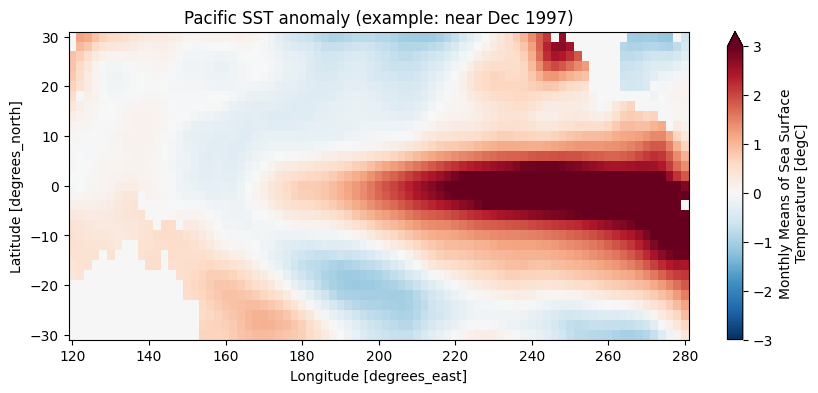

In [7]:
import matplotlib.pyplot as plt

sample = anom.sel(time="1997-12", method="nearest")  # strong El Niño winter
sample.plot(cmap="RdBu_r", vmin=-3, vmax=3, figsize=(10, 4))
plt.title("Pacific SST anomaly (example: near Dec 1997)")
plt.show()

## 6. Pull ONI and map each season to its middle month

DJF → January, JFM → February, … so ONI lines up with the SST monthly time axis.

In [8]:
import pandas as pd
import numpy as np

SEAS_TO_MONTH = {
    "DJF": 1, "JFM": 2, "FMA": 3, "MAM": 4,
    "AMJ": 5, "MJJ": 6, "JJA": 7, "JAS": 8,
    "ASO": 9, "SON": 10, "OND": 11, "NDJ": 12,
}

oni = pd.read_csv(
    "https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt",
    sep=r"\s+",
)
oni["month"] = oni["SEAS"].map(SEAS_TO_MONTH)
oni["time"] = pd.to_datetime(
    dict(year=oni["YR"], month=oni["month"], day=1)
)
oni = oni.set_index("time").sort_index()
oni = oni.loc["1950-01-01":]
oni[["SEAS", "YR", "ANOM"]].head(12)

,SEAS,YR,ANOM
time,,,
1950-01-01,DJF,1950,-1.32
1950-02-01,JFM,1950,-1.20
1950-03-01,FMA,1950,-1.12
1950-04-01,MAM,1950,-1.08
1950-05-01,AMJ,1950,-1.10
1950-06-01,MJJ,1950,-0.90
1950-07-01,JJA,1950,-0.62
1950-08-01,JAS,1950,-0.57
1950-09-01,ASO,1950,-0.56


## 7. Align ONI to every SST month

In [9]:
sst_times = pd.to_datetime(anom["time"].values)
# normalize to month start so it matches our ONI index
sst_month_starts = sst_times.to_period("M").to_timestamp()

oni_aligned = oni["ANOM"].reindex(sst_month_starts)
missing = int(oni_aligned.isna().sum())
print(f"Months in SST stack: {len(sst_month_starts)}")
print(f"Missing ONI after align: {missing}")

# drop months without ONI (usually the very newest SST months)
valid = ~oni_aligned.isna()
anom_aligned = anom.isel(time=np.where(valid.to_numpy())[0])
oni_by_month = oni_aligned[valid].to_numpy(dtype="float32")

print("Aligned anomaly shape:", anom_aligned.shape)
print("ONI length:", len(oni_by_month))
print("Latest aligned month:", pd.Timestamp(anom_aligned.time.values[-1]).date())
print("Latest ONI:", float(oni_by_month[-1]))

Months in SST stack: 919
Missing ONI after align: 1
Aligned anomaly shape: (918, 31, 81)
ONI length: 918
Latest aligned month: 2026-06-01
Latest ONI: 1.3899999856948853


In [10]:
# persist aligned ONI for Day 2
oni_out = DATA_DIR / "oni_monthly.csv"
pd.DataFrame(
    {
        "time": pd.to_datetime(anom_aligned.time.values),
        "oni": oni_by_month,
    }
).to_csv(oni_out, index=False)
print("Wrote", oni_out)
print("Day 1 checkpoint: anomaly maps + monthly ONI ready.")

Wrote /content/drive/MyDrive/ensocast/data/oni_monthly.csv
Day 1 checkpoint: anomaly maps + monthly ONI ready.
